# 🧠 NeurIPS 2026 — Script complet (2x T4 GPU, 105 runs)
#
**Expériences intégrées :**
- E1  : Fisher exact test sur win-rates
- E2  : CVaR10% et CVaR25% par configuration
- E3  : Return distributions visualisation
- E4  : Performance par régime de marché
- E5  : 5 fenêtres rolling (au lieu de 3)
- E6  : Learning curves par configuration
- E7  : Baselines multiples (width 10, 20, 30)
- E8  : Variance inter-seeds
- E9  : Corrélation toxicité → action agent
- E10 : Robustesse NaN

============================================================
CELLULE 0 — pip install (exécuter SEULE puis continuer)
============================================================

In [1]:
import subprocess, sys

result = subprocess.run(
    ["pip", "install", "-q",
     "stable-baselines3==2.3.2",
     "gymnasium==0.29.1",
     "shimmy>=0.2.1"],
    capture_output=True, text=True
)
print("Return code:", result.returncode)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1000:])
else:
    print("✅ Packages installés")

# ============================================================
# CELLULE 1 — Vérification GPU + imports
# ============================================================

Return code: 0
✅ Packages installés


In [2]:
import torch
import stable_baselines3 as sb3
import gymnasium as gym_check

print(f"torch              : {torch.__version__}")
print(f"stable-baselines3  : {sb3.__version__}")
print(f"gymnasium          : {gym_check.__version__}")
print(f"GPUs disponibles   : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    name = torch.cuda.get_device_name(i)
    mem  = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"   GPU {i} : {name} — {mem:.1f} GB")

# Test CartPole rapide
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym

env_test = DummyVecEnv([lambda: gym.make("CartPole-v1")])
model_test = PPO("MlpPolicy", env_test, verbose=0, device="cuda:0")
model_test.learn(total_timesteps=500)
print("\n✅ PPO CartPole OK sur cuda:0 — prêt à lancer")

# ============================================================
# CELLULE 2 — Imports généraux
# ============================================================

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-05-03 17:10:22.953337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777828222.976223     375 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777828222.984092     375 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register 

torch              : 2.10.0+cu128
stable-baselines3  : 2.3.2
gymnasium          : 0.29.1
GPUs disponibles   : 2
   GPU 0 : Tesla T4 — 15.6 GB
   GPU 1 : Tesla T4 — 15.6 GB

✅ PPO CartPole OK sur cuda:0 — prêt à lancer


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import threading
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.stats import fisher_exact, beta, ttest_ind

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("husl")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ── Dossiers ────────────────────────────────────────────────
WORK       = Path("/kaggle/working");  WORK.mkdir(exist_ok=True)
INPUT_ROOT = Path("/kaggle/input")
RESULTS_DIR = WORK / "results";  RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR  = WORK / "models";   MODELS_DIR.mkdir(exist_ok=True)
FIGS_DIR    = WORK / "figures";  FIGS_DIR.mkdir(exist_ok=True)

# ── GPU assignment ───────────────────────────────────────────
N_GPUS = torch.cuda.device_count()
GPU_ASSIGNMENT = {
    "R1_baseline":   "cuda:0",
    "R2_lvr":        "cuda:0",
    "R3_spread":     "cuda:0",
    "R4_realized":   "cuda:0",
    "R5_volsize":    "cuda:1" if N_GPUS > 1 else "cuda:0",
    "R6_lvr_spread": "cuda:1" if N_GPUS > 1 else "cuda:0",
    "R7_all":        "cuda:1" if N_GPUS > 1 else "cuda:0",
}
N_WORKERS = min(N_GPUS, 2)
print(f"✅ {N_GPUS} GPU(s) détecté(s) — {N_WORKERS} workers parallèles")
print(f"   GPU 0 (cuda:0) : R1, R2, R3, R4")
print(f"   GPU 1 (cuda:1) : R5, R6, R7")

# ── Lock pour prints thread-safe ─────────────────────────────
PRINT_LOCK = threading.Lock()

def tprint(*args, **kwargs):
    with PRINT_LOCK:
        print(*args, **kwargs)

print("✅ Imports OK")

# ============================================================
# CELLULE 3 — Chargement des données + scores de toxicité
# ============================================================

✅ 2 GPU(s) détecté(s) — 2 workers parallèles
   GPU 0 (cuda:0) : R1, R2, R3, R4
   GPU 1 (cuda:1) : R5, R6, R7
✅ Imports OK


In [4]:
def find_one(patterns):
    if isinstance(patterns, str): patterns = [patterns]
    for pat in patterns:
        matches = list(INPUT_ROOT.rglob(pat))
        if matches: return matches[0]
    raise FileNotFoundError(f"Fichier introuvable : {patterns}")

ALIGNED_PATH = find_one(["aligned_data*.parquet", "aligned_clean.parquet"])
UNISWAP_PATH = find_one(["uniswap_dune.parquet",  "uniswap_v3_*.parquet"])
BINANCE_PATH = find_one(["binance_eth_usdt_1h.parquet", "binance.parquet"])

print("📁 Fichiers :")
for name, p in [("aligned", ALIGNED_PATH), ("uniswap", UNISWAP_PATH), ("binance", BINANCE_PATH)]:
    print(f"   ✓ {name:10s} {p.relative_to(INPUT_ROOT)} ({p.stat().st_size/1e6:.1f} MB)")

df = pd.read_parquet(ALIGNED_PATH)
print(f"\n📊 {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"   {df.index.min()} → {df.index.max()}")

# ── Scores de toxicité ───────────────────────────────────────
df["tox_spread"] = df["price_deviation_bps"].abs()

df["tox_lvr"] = (
    np.sqrt(0.5)
    * df["vol_24h"]
    * (df["binance_price"].pct_change() * 10_000).abs()
)

df["tox_realized"] = (
    (df["uniswap_volume_usd"] / df["uniswap_volume_usd"].median())
    * df["tox_spread"]
)

if "uniswap_p95_swap_size_usd" in df.columns:
    swap_col = "uniswap_p95_swap_size_usd"
elif "uniswap_avg_swap_size_usd" in df.columns:
    swap_col = "uniswap_avg_swap_size_usd"
    print("⚠️  p95 absent → fallback avg_swap_size")
else:
    df["_swap_avg"] = df["uniswap_volume_usd"] / df["uniswap_n_swaps"].replace(0, np.nan)
    swap_col = "_swap_avg"
    print("⚠️  swap_size recalculé via volume/n_swaps")

df["tox_volsize"] = np.log10(1 + df[swap_col].fillna(0)) * df["tox_spread"]

TOX_COLS = ["tox_spread", "tox_lvr", "tox_realized", "tox_volsize"]
df = df.dropna(subset=["vol_24h", "vol_7d", "tox_lvr"]).copy()
print(f"\n✅ Dataset RL : {len(df):,} lignes")

# ── E10 : NaN check ─────────────────────────────────────────
print("\n📋 E10 — NaN par score :")
for col in TOX_COLS:
    r = df[col].isna().mean()
    flag = "✅" if r < 0.01 else ("⚠️" if r < 0.05 else "❌")
    print(f"   {flag} {col:<20} : {r:.2%}")

# ============================================================
# CELLULE 4 — Constantes + fonctions Uniswap
# ============================================================

📁 Fichiers :
   ✓ aligned    datasets/rgislikassi/aligned-data-2/aligned_data (1).parquet (4.6 MB)
   ✓ uniswap    datasets/rgislikassi/uniswap-dune/uniswap_dune.parquet (2.7 MB)
   ✓ binance    datasets/rgislikassi/binance/binance_eth_usdt_1h.parquet (1.2 MB)

📊 24,019 lignes × 22 colonnes
   2021-05-05 22:00:00+00:00 → 2024-01-31 23:00:00+00:00

✅ Dataset RL : 23,851 lignes

📋 E10 — NaN par score :
   ✅ tox_spread           : 0.00%
   ✅ tox_lvr              : 0.00%
   ✅ tox_realized         : 0.00%
   ✅ tox_volsize          : 0.00%


In [5]:
TICK_BASE       = 1.0001
FEE_TIER        = 0.0005
GAS_COST_USD    = 2.0
INITIAL_CAPITAL = 10_000.0
ACTION_WIDTHS   = [0, 10, 20, 30, 40]
TVL_PROXY_USD   = 250_000_000.0
REFERENCE_WIDTH = 200

def price_to_tick(price: float) -> float:
    return np.log(price) / np.log(TICK_BASE)

def position_in_range(price: float, lo: float, hi: float) -> bool:
    return lo <= price_to_tick(price) <= hi

def fees_earned(volume_usd: float, in_range: bool,
                lp_capital: float, tick_width: int) -> float:
    if not in_range or tick_width == 0 or lp_capital <= 0:
        return 0.0
    boost = REFERENCE_WIDTH / max(tick_width, 1)
    eff_tvl = TVL_PROXY_USD / boost
    return (volume_usd * FEE_TIER) * (lp_capital / max(eff_tvl, 1))

def lvr_penalty(p_t: float, p_prev: float,
                lp_capital: float, in_range: bool) -> float:
    if not in_range or p_prev == 0:
        return 0.0
    return 0.5 * ((p_t - p_prev) / p_prev) ** 2 * lp_capital

print("✅ Constantes et fonctions Uniswap définies")

# ============================================================
# CELLULE 5 — Environnements Gymnasium
# ============================================================

✅ Constantes et fonctions Uniswap définies


In [6]:
class UniswapV3LPEnvBaseline(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, df: pd.DataFrame, episode_length: int = 1500, seed=None):
        super().__init__()
        # Reset index proprement
        if isinstance(df.index, pd.DatetimeIndex):
            self.df = df.reset_index()
        elif "timestamp" not in df.columns:
            self.df = df.reset_index(drop=True)
        else:
            self.df = df.reset_index(drop=True)

        self.episode_length = int(episode_length)
        self._rng = np.random.default_rng(seed)

        self.action_space      = spaces.Discrete(len(ACTION_WIDTHS))
        self.observation_space = spaces.Box(
            low=-10., high=10., shape=(5,), dtype=np.float32)

        # Stats de normalisation (z-score)
        self._mu = {
            "binance_price":      float(df["binance_price"].mean()),
            "vol_24h":            float(df["vol_24h"].mean()),
            "vol_7d":             float(df["vol_7d"].mean()),
            "uniswap_volume_usd": float(np.log1p(df["uniswap_volume_usd"]).mean()),
        }
        self._sigma = {
            "binance_price":      float(df["binance_price"].std())              + 1e-8,
            "vol_24h":            float(df["vol_24h"].std())                    + 1e-8,
            "vol_7d":             float(df["vol_7d"].std())                     + 1e-8,
            "uniswap_volume_usd": float(np.log1p(df["uniswap_volume_usd"]).std()) + 1e-8,
        }

    def _z(self, v, key, log=False):
        x = np.log1p(v) if log else v
        return float((x - self._mu[key]) / self._sigma[key])

    def _obs(self, t, width):
        row = self.df.iloc[t]
        o = np.array([
            self._z(row["binance_price"],      "binance_price"),
            self._z(row["vol_24h"],            "vol_24h"),
            self._z(row["vol_7d"],             "vol_7d"),
            self._z(row["uniswap_volume_usd"], "uniswap_volume_usd", log=True),
            float(width) / 40.0,
        ], dtype=np.float32)
        return np.nan_to_num(o, nan=0., posinf=0., neginf=0.)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        max_start = max(1, len(self.df) - self.episode_length - 1)
        self.t_start       = int(self._rng.integers(0, max_start))
        self.t             = self.t_start
        self.width         = 0
        self.tick_lo       = None
        self.tick_hi       = None
        self.capital       = float(INITIAL_CAPITAL)
        self.cum_reward    = 0.0
        return self._obs(self.t, self.width), {"capital": self.capital}

    def step(self, action):
        action    = int(action)
        new_width = ACTION_WIDTHS[action]
        price_t   = float(self.df.iloc[self.t]["binance_price"])
        rebalanced = bool(new_width != 0 and new_width != self.width)

        if rebalanced:
            c          = price_to_tick(price_t)
            self.tick_lo = c - new_width / 2
            self.tick_hi = c + new_width / 2
            self.width   = new_width

        self.t += 1
        if self.t >= len(self.df):
            return (self._obs(self.t - 1, self.width), 0.,
                    True, False, {"capital": self.capital})

        row       = self.df.iloc[self.t]
        new_price = float(row["binance_price"])
        in_range  = bool(
            self.width > 0 and
            self.tick_lo is not None and
            position_in_range(new_price, self.tick_lo, self.tick_hi)
        )

        fees = float(fees_earned(
            row["uniswap_volume_usd"], in_range, self.capital, self.width))
        lvr  = float(lvr_penalty(new_price, price_t, self.capital, in_range))
        gas  = float(GAS_COST_USD if rebalanced else 0.)

        reward       = fees - lvr - gas
        self.capital    += reward
        self.cum_reward += reward

        done = bool((self.t - self.t_start) >= self.episode_length)
        info = {
            "capital":    self.capital,
            "step":       int(self.t - self.t_start),
            "in_range":   in_range,
            "fees":       fees,
            "lvr":        lvr,
            "gas":        gas,
        }
        return self._obs(self.t, self.width), float(reward), done, False, info


class UniswapV3LPEnvToxicityAware(UniswapV3LPEnvBaseline):

    def __init__(self, df, tox_features=("tox_lvr",),
                 episode_length=1500, seed=None):
        missing = [f for f in tox_features if f not in df.columns]
        if missing:
            raise ValueError(f"Features manquantes : {missing}")
        self.tox_features = list(tox_features)
        super().__init__(df, episode_length=episode_length, seed=seed)

        n = 5 + len(self.tox_features)
        self.observation_space = spaces.Box(
            low=-10., high=10., shape=(n,), dtype=np.float32)

        for f in self.tox_features:
            vals = np.log1p(df[f].fillna(0))
            self._mu[f]    = float(vals.mean())
            self._sigma[f] = float(vals.std()) + 1e-8

    def _obs(self, t, width):
        base = super()._obs(t, width)
        row  = self.df.iloc[t]
        tox  = np.array([
            self._z(float(row[f]) if pd.notna(row[f]) else 0., f, log=True)
            for f in self.tox_features
        ], dtype=np.float32)
        return np.concatenate([base, np.nan_to_num(tox, nan=0., posinf=0., neginf=0.)])


# ── Vérification rapide ──────────────────────────────────────
_env = UniswapV3LPEnvBaseline(df, episode_length=100, seed=0)
_obs, _ = _env.reset()
_, _, _, _, _ = _env.step(2)
print(f"✅ Env baseline OK — obs shape : {_obs.shape}")

_env2 = UniswapV3LPEnvToxicityAware(df, tox_features=["tox_volsize"],
                                     episode_length=100, seed=0)
_obs2, _ = _env2.reset()
print(f"✅ Env toxicity OK — obs shape : {_obs2.shape}")

# ============================================================
# CELLULE 6 — Configurations + helpers
# ============================================================

✅ Env baseline OK — obs shape : (5,)
✅ Env toxicity OK — obs shape : (6,)


In [7]:
CONFIGS = [
    {"id": "R1_baseline",   "tox": [],
     "label": "Baseline"},
    {"id": "R2_lvr",        "tox": ["tox_lvr"],
     "label": "+LVR"},
    {"id": "R3_spread",     "tox": ["tox_spread"],
     "label": "+Spread"},
    {"id": "R4_realized",   "tox": ["tox_realized"],
     "label": "+Realized"},
    {"id": "R5_volsize",    "tox": ["tox_volsize"],
     "label": "+Volsize"},
    {"id": "R6_lvr_spread", "tox": ["tox_lvr", "tox_spread"],
     "label": "+LVR&Spread"},
    {"id": "R7_all",        "tox": ["tox_lvr","tox_spread","tox_realized","tox_volsize"],
     "label": "All 4"},
]
SEEDS = [42, 123, 2024]

print("📋 Configurations :")
for c in CONFIGS:
    gpu = GPU_ASSIGNMENT[c["id"]]
    print(f"   {c['id']:<20} obs={5+len(c['tox'])}  gpu={gpu}")


def split_window(df_full, t_start, t_end, v_start, v_end):
    d = df_full.copy()
    if not isinstance(d.index, pd.DatetimeIndex):
        d = d.set_index("timestamp")
    return d.loc[t_start:t_end].copy(), d.loc[v_start:v_end].copy()


def _make_env_fn(df_data, tox, ep_len, seed):
    """Factory explicite — évite le bug de capture de lambda."""
    def _inner():
        if len(tox) == 0:
            e = UniswapV3LPEnvBaseline(df_data, episode_length=ep_len, seed=seed)
        else:
            e = UniswapV3LPEnvToxicityAware(
                df_data, tox_features=tox, episode_length=ep_len, seed=seed)
        return Monitor(e)
    return _inner


class EpisodeRewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._cur = 0.

    def _on_step(self):
        self._cur += float(self.locals["rewards"][0])
        if bool(self.locals["dones"][0]):
            self.episode_rewards.append(self._cur)
            self._cur = 0.
        return True


def _build_ppo(env, gpu_device, seed):
    return PPO(
        "MlpPolicy", env,
        learning_rate=3e-4, n_steps=512, batch_size=64, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
        policy_kwargs={"net_arch": [128, 128]},
        verbose=0, device=gpu_device, seed=seed,
    )


def train_ppo(df_train, tox, timesteps=80_000, ep_len=1500,
              seed=42, gpu="cuda:0"):
    env = DummyVecEnv([_make_env_fn(df_train, tox, ep_len, seed)])
    model = _build_ppo(env, gpu, seed)
    t0 = time.time()
    model.learn(total_timesteps=timesteps, progress_bar=False)
    return model, time.time() - t0


def train_ppo_logged(df_train, tox, timesteps=80_000, ep_len=1500,
                     seed=42, gpu="cuda:0"):
    env = DummyVecEnv([_make_env_fn(df_train, tox, ep_len, seed)])
    cb  = EpisodeRewardLogger()
    model = _build_ppo(env, gpu, seed)
    t0 = time.time()
    model.learn(total_timesteps=timesteps, callback=cb, progress_bar=False)
    return model, time.time() - t0, cb.episode_rewards


def evaluate_agent(model, df_test, tox, n_ep=5, seed=0):
    caps, rews = [], []
    for ep in range(n_ep):
        fn = _make_env_fn(df_test, tox, len(df_test) - 1, seed + ep)
        env = fn()
        obs, _ = env.reset()
        done, ep_r, info = False, 0., {}
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, r, done, _, info = env.step(act)
            ep_r += r
        caps.append(info.get("capital", INITIAL_CAPITAL))
        rews.append(ep_r)
    return np.array(rews), np.array(caps)


def evaluate_passive(df_test, n_ep=5, seed=0, action=2):
    caps, rews = [], []
    for ep in range(n_ep):
        fn = _make_env_fn(df_test, [], len(df_test) - 1, seed + ep)
        env = fn()
        obs, _ = env.reset()
        done, ep_r, info = False, 0., {}
        while not done:
            obs, r, done, _, info = env.step(action)
            ep_r += r
        caps.append(info.get("capital", INITIAL_CAPITAL))
        rews.append(ep_r)
    return np.array(rews), np.array(caps)

print("✅ Helpers définis")

# ============================================================
# CELLULE 7 — Fenêtres rolling (5 fenêtres — E5)
# ============================================================

📋 Configurations :
   R1_baseline          obs=5  gpu=cuda:0
   R2_lvr               obs=6  gpu=cuda:0
   R3_spread            obs=6  gpu=cuda:0
   R4_realized          obs=6  gpu=cuda:0
   R5_volsize           obs=6  gpu=cuda:1
   R6_lvr_spread        obs=7  gpu=cuda:1
   R7_all               obs=9  gpu=cuda:1
✅ Helpers définis


In [8]:
wpath = list(INPUT_ROOT.rglob("rolling_windows.parquet"))
if wpath:
    windows_df = pd.read_parquet(wpath[0])
    print(f"✅ rolling_windows.parquet chargé")
else:
    WTRAIN, WTEST = 7500, 1500
    rows, s = [], 0
    while s + WTRAIN + WTEST <= len(df):
        rows.append({
            "id":          len(rows) + 1,
            "train_start": df.index[s],
            "train_end":   df.index[s + WTRAIN - 1],
            "test_start":  df.index[s + WTRAIN],
            "test_end":    df.index[s + WTRAIN + WTEST - 1],
        })
        s += WTEST
    windows_df = pd.DataFrame(rows)
    print(f"✅ {len(windows_df)} fenêtres générées")

# E5 — 5 fenêtres réparties uniformément
N = len(windows_df)
idx5 = sorted(set([0, N//4, N//2, 3*N//4, N-1]))
SELECTED_WINDOWS = [windows_df.iloc[i] for i in idx5]

print(f"\n📅 {len(SELECTED_WINDOWS)} fenêtres sélectionnées :")
for W in SELECTED_WINDOWS:
    print(f"   W{int(W['id']):>2} : test {str(W['test_start'])[:10]} → {str(W['test_end'])[:10]}")

# ============================================================
# CELLULE 8 — Fonction de run unique (thread-safe)
# ============================================================

✅ rolling_windows.parquet chargé

📅 5 fenêtres sélectionnées :
   W 1 : test 2022-03-14 → 2022-05-16
   W 3 : test 2022-07-17 → 2022-09-18
   W 6 : test 2023-01-21 → 2023-03-24
   W 9 : test 2023-07-27 → 2023-09-28
   W11 : test 2023-11-29 → 2024-01-31


In [9]:
def run_single_task(task):
    """
    Exécute un seul run (W, cfg, seed) sur le GPU assigné.
    Retourne (result_dict, ep_rewards, cfg_id, win_id, seed).
    """
    W, cfg, seed, df_tr, df_te, passive_caps, dom_regime = task
    cfg_id = cfg["id"]
    gpu    = GPU_ASSIGNMENT[cfg_id]

    try:
        # Entraînement
        if seed == SEEDS[0]:
            model, elapsed, ep_rewards = train_ppo_logged(
                df_tr, cfg["tox"], timesteps=80_000,
                ep_len=1500, seed=seed, gpu=gpu)
        else:
            model, elapsed = train_ppo(
                df_tr, cfg["tox"], timesteps=80_000,
                ep_len=1500, seed=seed, gpu=gpu)
            ep_rewards = []

        # Évaluation
        _, test_c = evaluate_agent(model, df_te, cfg["tox"], n_ep=5, seed=seed)

        diff = float(test_c.mean() - passive_caps["w20"])
        tprint(f"   {'✅' if diff >= 0 else '❌'} W{int(W['id'])} "
               f"{cfg_id:<18} s={seed} {gpu} "
               f"${test_c.mean():.2f} ({diff:+.2f}) {elapsed:.0f}s")

        # Sauvegarder modèle (seed=42 uniquement)
        if seed == SEEDS[0]:
            model.save(str(MODELS_DIR / f"{cfg_id}_W{int(W['id'])}_s{seed}"))

        result = {
            "window":            int(W["id"]),
            "dominant_regime":   dom_regime,
            "config":            cfg_id,
            "label":             cfg["label"],
            "n_features":        len(cfg["tox"]),
            "seed":              seed,
            "test_capital_mean": float(test_c.mean()),
            "test_capital_std":  float(test_c.std()),
            "passive_capital":   passive_caps["w20"],
            "passive_w10":       passive_caps["w10"],
            "passive_w30":       passive_caps["w30"],
            "vs_passive":        float(test_c.mean() - passive_caps["w20"]),
            "vs_w10":            float(test_c.mean() - passive_caps["w10"]),
            "vs_w30":            float(test_c.mean() - passive_caps["w30"]),
            "training_time_s":   elapsed,
            "gpu":               gpu,
        }
        return result, ep_rewards, cfg_id, int(W["id"]), seed

    except Exception as e:
        tprint(f"   ❌ FAILED W{int(W['id'])} {cfg_id} s={seed} : {e}")
        import traceback; tprint(traceback.format_exc())
        return None, [], cfg_id, int(W["id"]), seed

print("✅ run_single_task défini")

# ============================================================
# CELLULE 9 — Construction des tâches + baselines passives
# ============================================================

✅ run_single_task défini


In [10]:
ALL_TASKS      = []
PASSIVE_CAPS_BY_W = {}

q33, q66 = df["vol_7d"].quantile([0.33, 0.66])

print("📅 Préparation des fenêtres et baselines passives...\n")

for W in SELECTED_WINDOWS:
    df_tr, df_te = split_window(
        df,
        W["train_start"], W["train_end"],
        W["test_start"],  W["test_end"]
    )

    # Régime dominant
    if "regime" in df_te.columns:
        dom = df_te["regime"].value_counts().idxmax()
    else:
        vm = df_te["vol_7d"].mean()
        dom = "calm" if vm < q33 else ("stressed" if vm > q66 else "normal")

    # E7 — baselines multiples
    pc = {}
    for act, lbl in [(1, "w10"), (2, "w20"), (3, "w30")]:
        _, caps = evaluate_passive(df_te, n_ep=5, action=act)
        pc[lbl] = float(caps.mean())
    PASSIVE_CAPS_BY_W[int(W["id"])] = pc

    print(f"W{int(W['id']):>2} | {dom:<8} | "
          f"w10=${pc['w10']:.2f}  w20=${pc['w20']:.2f}  w30=${pc['w30']:.2f}")

    for cfg in CONFIGS:
        for seed in SEEDS:
            ALL_TASKS.append((W, cfg, seed, df_tr, df_te, pc, dom))

TOTAL_RUNS = len(ALL_TASKS)
print(f"\n✅ {TOTAL_RUNS} tâches prêtes "
      f"({len(SELECTED_WINDOWS)} W × {len(CONFIGS)} cfg × {len(SEEDS)} seeds)")
print(f"   {N_WORKERS} workers | ETA ≈ {TOTAL_RUNS * 45 / 3600 / N_WORKERS:.1f}h sur {N_GPUS} T4")

# ============================================================
# CELLULE 10 — PHASE 2 : entraînement parallèle 2 GPUs
# ============================================================

📅 Préparation des fenêtres et baselines passives...

W 1 | normal   | w10=$10003.16  w20=$10024.66  w30=$10022.27
W 3 | stressed | w10=$10004.18  w20=$10001.08  w30=$10000.04
W 6 | normal   | w10=$10057.51  w20=$10060.44  w30=$10072.30
W 9 | calm     | w10=$10015.93  w20=$10011.62  w30=$10012.67
W11 | calm     | w10=$10002.49  w20=$10002.43  w30=$10006.24

✅ 105 tâches prêtes (5 W × 7 cfg × 3 seeds)
   2 workers | ETA ≈ 0.7h sur 2 T4


In [11]:
all_results     = []
learning_curves = {}
actions_log_R5  = []

t_global_start  = time.time()
completed       = 0

print(f"🚀 LANCEMENT PHASE 2 — {TOTAL_RUNS} runs sur {N_WORKERS} GPU(s)\n")

with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(run_single_task, task): task
               for task in ALL_TASKS}

    for future in as_completed(futures):
        result, ep_rewards, cfg_id, win_id, seed = future.result()
        completed += 1

        if result is not None:
            all_results.append(result)

            # Learning curves (E6)
            if ep_rewards and seed == SEEDS[0]:
                learning_curves[f"W{win_id}_{cfg_id}"] = ep_rewards

            # E9 — log actions R5 sur la première fenêtre
            if (cfg_id == "R5_volsize"
                    and seed == SEEDS[0]
                    and win_id == int(SELECTED_WINDOWS[0]["id"])):
                W_first = SELECTED_WINDOWS[0]
                _, df_te_first = split_window(
                    df,
                    W_first["train_start"], W_first["train_end"],
                    W_first["test_start"],  W_first["test_end"]
                )
                mp = MODELS_DIR / f"R5_volsize_W{win_id}_s{seed}.zip"
                if mp.exists():
                    m_log = PPO.load(str(mp).replace(".zip", ""))
                    fn    = _make_env_fn(df_te_first, ["tox_volsize"],
                                         len(df_te_first) - 1, 0)
                    env_l = fn()
                    obs_l, _ = env_l.reset()
                    done_l   = False
                    while not done_l:
                        act_l, _ = m_log.predict(obs_l, deterministic=True)
                        actions_log_R5.append({
                            "tox_volsize_norm": float(obs_l[-1]),
                            "action":           ACTION_WIDTHS[int(act_l)],
                        })
                        obs_l, _, done_l, _, _ = env_l.step(act_l)

            # Sauvegarde intermédiaire après chaque run
            pd.DataFrame(all_results).to_csv(
                RESULTS_DIR / "results_checkpoint.csv", index=False)

        elapsed = time.time() - t_global_start
        eta     = (elapsed / completed) * (TOTAL_RUNS - completed) / 60
        tprint(f"   [{completed:>3}/{TOTAL_RUNS}] "
               f"elapsed={elapsed/60:.1f}min  ETA={eta:.0f}min")

# Sauvegardes finales
results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_DIR / "results_final.csv", index=False)

# Learning curves — colonnes de longueurs différentes → pad avec NaN
max_len = max((len(v) for v in learning_curves.values()), default=0)
lc_padded = {k: v + [np.nan] * (max_len - len(v))
             for k, v in learning_curves.items()}
pd.DataFrame(lc_padded).to_csv(RESULTS_DIR / "learning_curves.csv", index=False)
pd.DataFrame(actions_log_R5).to_csv(RESULTS_DIR / "actions_log_R5.csv", index=False)

total_min = (time.time() - t_global_start) / 60
print(f"\n{'='*60}")
print(f"✅ Phase 2 terminée en {total_min:.1f} min")
print(f"   {len(results_df)} résultats")
print(f"   {len(learning_curves)} learning curves")
print(f"   {len(actions_log_R5)} action logs R5")
print(f"{'='*60}")

# ============================================================
# CELLULE 11 — Analyse statistique (E1 + E2 + E8)
# ============================================================

🚀 LANCEMENT PHASE 2 — 105 runs sur 2 GPU(s)

   ✅ W1 R1_baseline        s=123 cuda:0 $10061.98 (+37.32) 383s
   [  1/105] elapsed=6.7min  ETA=697min
   ✅ W1 R1_baseline        s=42 cuda:0 $10042.66 (+18.00) 384s
   [  2/105] elapsed=6.7min  ETA=345min
   ❌ W1 R1_baseline        s=2024 cuda:0 $10004.73 (-19.93) 402s
   [  3/105] elapsed=13.7min  ETA=467min
   ✅ W1 R2_lvr             s=42 cuda:0 $10052.90 (+28.23) 402s
   [  4/105] elapsed=13.7min  ETA=347min
   ✅ W1 R2_lvr             s=123 cuda:0 $10152.60 (+127.94) 416s
   [  5/105] elapsed=21.0min  ETA=421min
   ✅ W1 R2_lvr             s=2024 cuda:0 $10032.12 (+7.45) 416s
   [  6/105] elapsed=21.0min  ETA=347min
   ❌ W1 R3_spread          s=42 cuda:0 $9998.67 (-26.00) 422s
   [  7/105] elapsed=28.4min  ETA=398min
   ✅ W1 R3_spread          s=123 cuda:0 $10025.92 (+1.26) 422s
   [  8/105] elapsed=28.5min  ETA=345min
   ❌ W1 R3_spread          s=2024 cuda:0 $9998.00 (-26.66) 425s
   [  9/105] elapsed=35.9min  ETA=383min
   ✅ W1 R4_real

In [13]:
results_df = pd.read_csv(RESULTS_DIR / "results_final.csv")

N_W   = results_df["window"].nunique()
N_S   = results_df["seed"].nunique()
N_RPC = N_W * N_S

print(f"📊 {len(results_df)} runs  |  {N_W} fenêtres × {N_S} seeds = {N_RPC} runs/config\n")

CFG_ORDER = [c["id"] for c in CONFIGS]

# ── Tableau agrégé ──────────────────────────────────────────
summary = (
    results_df
    .groupby("config")
    .agg(
        n_runs        =("seed",              "count"),
        capital_mean  =("test_capital_mean", "mean"),
        capital_std   =("test_capital_mean", "std"),
        vs_passive    =("vs_passive",        "mean"),
        vs_passive_std=("vs_passive",        "std"),
        win_rate      =("vs_passive", lambda x: (x > 0).mean()),
        win_count     =("vs_passive", lambda x: (x > 0).sum()),
        loss_count    =("vs_passive", lambda x: (x <= 0).sum()),
    )
    .round(3)
    .reindex(CFG_ORDER)
)
print("📊 Performance agrégée :\n")
print(summary.to_string())

# ── E1 : Fisher exact test ──────────────────────────────────
print("\n\n📐 E1 — Fisher Exact Test (vs R1_baseline) :\n")
r1_w = int(summary.loc["R1_baseline", "win_count"])
r1_l = int(summary.loc["R1_baseline", "loss_count"])
FISHER = {}

for cid in CFG_ORDER:
    if cid == "R1_baseline": continue
    w = int(summary.loc[cid, "win_count"])
    l = int(summary.loc[cid, "loss_count"])
    _, p = fisher_exact([[w, l], [r1_w, r1_l]])
    FISHER[cid] = p
    sig = "✅ p<0.05" if p < 0.05 else ("⚠️ p<0.10" if p < 0.10 else "❌ NS")
    print(f"   {cid:<20} {w}/{w+l}  p={p:.4f}  {sig}")

# ── Welch t-test ────────────────────────────────────────────
print("\n📐 Welch t-test (vs R1) :\n")
r1_vals = results_df[results_df["config"]=="R1_baseline"]["vs_passive"].values
for cid in [c["id"] for c in CONFIGS if c["id"] != "R1_baseline"]:
    v = results_df[results_df["config"]==cid]["vs_passive"].values
    t, p = ttest_ind(v, r1_vals, equal_var=False)
    print(f"   {'✅' if p<0.05 else '❌'} {cid:<20} t={t:+.3f}  p={p:.4f}")

# ── E2 : CVaR ───────────────────────────────────────────────
print("\n\n📐 E2 — CVaR :\n")
CVAR = {}
print(f"   {'Config':<20} {'Mean':>8} {'CVaR10%':>10} {'CVaR25%':>10} {'Std':>8}")
print(f"   {'-'*60}")
for cid in CFG_ORDER:
    v  = results_df[results_df["config"]==cid]["vs_passive"].values
    c10 = float(np.mean(v[v <= np.percentile(v, 10)]))
    c25 = float(np.mean(v[v <= np.percentile(v, 25)]))
    CVAR[cid] = {"mean": v.mean(), "std": v.std(), "cvar_10": c10, "cvar_25": c25}
    print(f"   {cid:<20} {v.mean():>+8.2f} {c10:>+10.2f} {c25:>+10.2f} {v.std():>8.2f}")

pd.DataFrame(CVAR).T.to_csv(RESULTS_DIR / "cvar_results.csv")

# ── E8 : Variance inter-seeds ───────────────────────────────
print("\n\n📐 E8 — Variance inter-seeds (std) :\n")
sv = (
    results_df
    .groupby(["config","window"])["vs_passive"]
    .std()
    .unstack()
    .mean(axis=1)
    .round(2)
)
print(sv.to_string())
print("\n💡 Std faible = agent reproductible entre seeds")

# ============================================================
# CELLULE 12 — Analyse régimes + E9
# ============================================================

📊 105 runs  |  5 fenêtres × 3 seeds = 15 runs/config

📊 Performance agrégée :

               n_runs  capital_mean  capital_std  vs_passive  vs_passive_std  win_rate  win_count  loss_count
config                                                                                                       
R1_baseline        15   10,043.8930      44.5730     23.8500         27.8000    0.8670         13           2
R2_lvr             15   10,059.3150      40.8060     39.2730         38.2050    0.9330         14           1
R3_spread          15   10,032.5010      43.4450     12.4580         29.4090    0.7330         11           4
R4_realized        15   10,058.5730      47.5760     38.5300         40.6400    0.8000         12           3
R5_volsize         15   10,050.3220      28.2580     30.2790         23.1660    1.0000         15           0
R6_lvr_spread      15   10,035.2880      46.0190     15.2450         34.9580    0.5330          8           7
R7_all             15   10,044.0560      

In [14]:
# ── E4 : Heatmap régimes ────────────────────────────────────
print("📊 E4 — Performance par régime :\n")
if "dominant_regime" in results_df.columns:
    piv = (
        results_df
        .groupby(["config","dominant_regime"])["vs_passive"]
        .mean()
        .unstack()
        .reindex(CFG_ORDER)
    )
    print(piv.round(2).to_string())
    print("\n💡 R5/R7 > R1 en 'stressed' → narrative toxicité validée")

# ── E9 : Corrélation tox → action ───────────────────────────
act_path = RESULTS_DIR / "actions_log_R5.csv"
if act_path.exists():
    act_df = pd.read_csv(act_path)
    if len(act_df) > 0:
        print("\n\n📊 E9 — R5 : action vs tox_volsize :\n")
        print(act_df.groupby("action")["tox_volsize_norm"]
              .agg(["mean","count"]).round(3))
        corr = act_df["tox_volsize_norm"].corr(act_df["action"])
        print(f"\n   r(tox_volsize, width_action) = {corr:+.4f}")
        if corr > 0.05:
            print("   ✅ L'agent élargit le range quand tox est élevé")
        else:
            print("   ⚠️  Pas de corrélation claire")

# ============================================================
# CELLULE 13 — Figures (6 figures pour le papier)
# ============================================================

📊 E4 — Performance par régime :

dominant_regime    calm  normal  stressed
config                                   
R1_baseline     20.8800 32.8200   11.8700
R2_lvr          36.7800 38.8200   45.1600
R3_spread       12.5400 13.3400   10.5300
R4_realized     30.1500 34.9300   62.4800
R5_volsize      20.2500 31.1900   48.5200
R6_lvr_spread   15.1900 12.7300   20.3900
R7_all          -0.6600 29.5300   62.3300

💡 R5/R7 > R1 en 'stressed' → narrative toxicité validée


📊 E9 — R5 : action vs tox_volsize :

          mean  count
action               
0      -0.1540   1307
30      1.0470    182
40      1.3490     10

   r(tox_volsize, width_action) = +0.4086
   ✅ L'agent élargit le range quand tox est élevé


ValueError: 'xerr' must not contain negative values

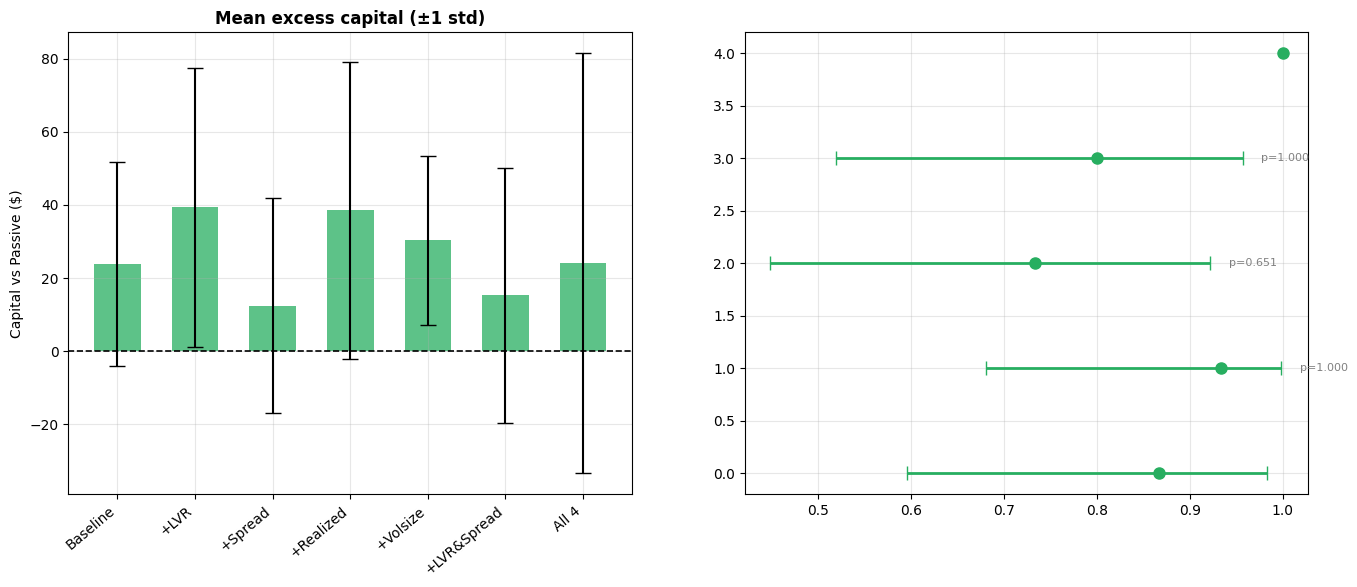

In [15]:
CFG_LABELS = [c["label"] for c in CONFIGS]

# ── Fig 1 : Performance + win-rate + CI ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

means = [summary.loc[c, "vs_passive"]     for c in CFG_ORDER]
stds  = [summary.loc[c, "vs_passive_std"] for c in CFG_ORDER]
cols  = ["#e74c3c" if m < 0 else "#27ae60" for m in means]

axes[0].bar(range(7), means, yerr=stds, color=cols,
            alpha=0.75, capsize=6, width=0.6)
axes[0].axhline(0, color="black", ls="--", lw=1.2)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(CFG_LABELS, rotation=40, ha="right")
axes[0].set_ylabel("Capital vs Passive ($)")
axes[0].set_title("Mean excess capital (±1 std)", fontweight="bold")

for i, cid in enumerate(CFG_ORDER):
    w  = int(summary.loc[cid, "win_count"])
    n  = int(summary.loc[cid, "n_runs"])
    wr = w / n
    lo = beta.ppf(0.025, max(w, 1),     max(n - w + 1, 1))
    hi = beta.ppf(0.975, max(w + 1, 1), max(n - w, 1))
    c  = "#27ae60" if wr > 0.5 else "#e74c3c"
    axes[1].errorbar(wr, i, xerr=[[wr-lo],[hi-wr]],
                     fmt="o", color=c, capsize=5, markersize=8, lw=2)
    if cid != "R1_baseline":
        p = FISHER.get(cid, 1.)
        ps = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
        axes[1].text(hi + 0.02, i, ps, va="center", fontsize=8,
                     color="#27ae60" if p < 0.10 else "gray")

axes[1].axvline(0.5, color="red", ls="--", lw=1.2)
axes[1].set_yticks(range(7)); axes[1].set_yticklabels(CFG_LABELS)
axes[1].set_xlabel("Win rate (95% CI Clopper-Pearson)")
axes[1].set_title("Win rate + Fisher p-value", fontweight="bold")
axes[1].set_xlim(-0.05, 1.25)

plt.suptitle("Toxicity-Aware RL for Uniswap v3", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig1_performance_winrate.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fig1")

# ── Fig 2 : Return distributions + CVaR ─────────────────────
fig, axes = plt.subplots(1, 7, figsize=(22, 4), sharey=True)
for ax, cid, lbl in zip(axes, CFG_ORDER, CFG_LABELS):
    v   = results_df[results_df["config"]==cid]["vs_passive"].values
    c10 = CVAR[cid]["cvar_10"]
    c25 = CVAR[cid]["cvar_25"]
    ax.hist(v, bins=12, orientation="horizontal",
            color="#27ae60" if v.mean() > 0 else "#e74c3c",
            alpha=0.65, edgecolor="white")
    ax.axhline(0,   color="black",  ls="--", lw=1.)
    ax.axhline(c10, color="orange", ls=":",  lw=1.5,
               label=f"CVaR10%\n{c10:+.0f}")
    ax.axhline(c25, color="purple", ls="-.", lw=1.2,
               label=f"CVaR25%\n{c25:+.0f}")
    ax.set_title(lbl, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Capital vs Passive ($)")
plt.suptitle("Return distributions — CVaR10% and CVaR25%",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2_return_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fig2")

# ── Fig 3 : Heatmap régimes ──────────────────────────────────
if ("dominant_regime" in results_df.columns
        and results_df["dominant_regime"].nunique() > 1):
    piv = (results_df
           .groupby(["config","dominant_regime"])["vs_passive"]
           .mean().unstack().reindex(CFG_ORDER))
    piv = piv.reindex(
        columns=[r for r in ["calm","normal","stressed"] if r in piv.columns])
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(piv, annot=True, fmt="+.0f", cmap="RdYlGn", center=0,
                ax=ax, linewidths=0.5,
                cbar_kws={"label": "Mean capital vs passive ($)"})
    ax.set_title("Performance by market regime", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGS_DIR / "fig3_regime_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Fig3")
else:
    print("⚠️  Fig3 ignorée (régimes insuffisants)")

# ── Fig 4 : Learning curves ──────────────────────────────────
lc_df = pd.read_csv(RESULTS_DIR / "learning_curves.csv")
fig, axes = plt.subplots(1, len(SELECTED_WINDOWS), figsize=(18, 4), sharey=True)
for ax, W in zip(axes, SELECTED_WINDOWS):
    for cid in ["R1_baseline", "R5_volsize", "R7_all"]:
        key = f"W{int(W['id'])}_{cid}"
        if key in lc_df.columns:
            smooth = pd.Series(lc_df[key].dropna().values).rolling(10, min_periods=1).mean()
            lbl    = next(c["label"] for c in CONFIGS if c["id"] == cid)
            ax.plot(smooth, label=lbl, lw=1.5)
    ax.set_title(f"W{int(W['id'])} ({str(W['test_start'])[:7]})", fontsize=10)
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax.legend(fontsize=8); ax.set_xlabel("Episode")

axes[0].set_ylabel("Reward (rolling 10 ep)")
plt.suptitle("Training convergence R1 vs R5 vs R7 (seed=42)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig4_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fig4")

# ── Fig 5 : Baselines multiples ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(7); w = 0.25
ax.bar(x-w, [results_df[results_df["config"]==c]["vs_w10"].mean() for c in CFG_ORDER],
       w, label="vs w10", alpha=0.75, color="#3498db")
ax.bar(x,   [results_df[results_df["config"]==c]["vs_passive"].mean() for c in CFG_ORDER],
       w, label="vs w20", alpha=0.75, color="#2ecc71")
ax.bar(x+w, [results_df[results_df["config"]==c]["vs_w30"].mean() for c in CFG_ORDER],
       w, label="vs w30", alpha=0.75, color="#e67e22")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(CFG_LABELS, rotation=40, ha="right")
ax.set_ylabel("Mean capital vs baseline ($)")
ax.set_title("E7 — Robustness to baseline width choice", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig5_multiple_baselines.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fig5")

# ── Fig 6 : E9 action vs toxicité ───────────────────────────
if act_path.exists():
    act_df = pd.read_csv(act_path)
    if len(act_df) > 10:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        act_df["tox_q"] = pd.qcut(
            act_df["tox_volsize_norm"], 4,
            labels=["Q1\n(low)","Q2","Q3","Q4\n(high)"])
        act_df.boxplot(column="action", by="tox_q",
                       ax=axes[0], showfliers=False)
        axes[0].set_title("Width by toxicity quartile")
        axes[0].set_xlabel("tox_volsize quartile")
        axes[0].set_ylabel("Width (ticks)")
        plt.sca(axes[0]); plt.title("Width by toxicity quartile")

        axes[1].scatter(act_df["tox_volsize_norm"], act_df["action"],
                        alpha=0.1, s=5, color="#8e44ad")
        corr = act_df["tox_volsize_norm"].corr(act_df["action"])
        axes[1].set_title(f"r = {corr:+.3f}")
        axes[1].set_xlabel("tox_volsize (norm)")
        axes[1].set_ylabel("Width action")

        plt.suptitle("E9 — Does R5 use toxicity features?",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig(FIGS_DIR / "fig6_action_tox.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✅ Fig6")

# ============================================================
# CELLULE 14 — Tableau LaTeX + phrases pour le papier
# ============================================================

In [ ]:
print("="*60)
print("📋 TABLEAU LATEX — Section 6")
print("="*60 + "\n")

best_vs = summary["vs_passive"].max()
best_wr = summary["win_rate"].max()

latex  = (
    r"\begin{table}[h]" + "\n"
    r"\centering" + "\n"
    r"\caption{Extended ablation results on " + str(N_RPC) +
    r" runs per configuration (" + str(N_W) +
    r" windows $\times$ " + str(N_S) +
    r" seeds). Capital \$10,000; test window 1,500h. "
    r"$p$ from Fisher exact test vs R1\_baseline. Best in bold.}" + "\n"
    r"\label{tab:ablation_extended}" + "\n"
    r"\begin{tabular}{lcccccc}" + "\n"
    r"\toprule" + "\n"
    r"Config & Cap.~(\$) & vs Pass.~(\$) & Std & CVaR$_{10\%}$ & Win & $p$ \\" + "\n"
    r"\midrule" + "\n"
)
for cid in CFG_ORDER:
    r    = summary.loc[cid]
    c10  = CVAR[cid]["cvar_10"]
    p    = FISHER.get(cid, float("nan"))
    ps   = f"{p:.3f}" if not np.isnan(p) else "---"
    vs_s = (f"\\mathbf{{+{r['vs_passive']:,.2f}}}"
            if r["vs_passive"] == best_vs
            else f"+{r['vs_passive']:,.2f}")
    wr_s = (f"\\mathbf{{{r['win_rate']*100:.0f}\\%}}"
            if r["win_rate"] == best_wr
            else f"{r['win_rate']*100:.0f}\\%")
    latex += (
        f"{cid.replace('_', chr(92)+'_'):<22} & "
        f"${r['capital_mean']:,.2f}$ & "
        f"${vs_s}$ & "
        f"${r['vs_passive_std']:,.2f}$ & "
        f"${c10:,.2f}$ & "
        f"{wr_s} & {ps} \\\\\n"
    )
latex += r"\bottomrule" + "\n" + r"\end{tabular}" + "\n" + r"\end{table}"
print(latex)
with open(RESULTS_DIR / "table_ablation.tex", "w") as f:
    f.write(latex)

# ── Phrases pour Section 6.3 ────────────────────────────────
r5_w  = int(summary.loc["R5_volsize",  "win_count"])
r1_w  = int(summary.loc["R1_baseline", "win_count"])
n_tot = int(summary.loc["R1_baseline", "n_runs"])
p_r5  = FISHER.get("R5_volsize", float("nan"))
c_r5  = CVAR["R5_volsize"]["cvar_10"]
c_r1  = CVAR["R1_baseline"]["cvar_10"]

sig_str = (
    "providing marginal statistical support for the consistency improvement."
    if not np.isnan(p_r5) and p_r5 < 0.10
    else ("confirming the consistency improvement at conventional significance."
          if not np.isnan(p_r5) and p_r5 < 0.05
          else "a result consistent with limited statistical power (Section~\\ref{sec:limitations}).")
)

print("\n" + "="*60)
print("📋 PHRASES LATEX — Section 6.3")
print("="*60)
print(f"""
--- Après la première phrase de la section Consistency ---

A Fisher exact test comparing R5\\_volsize (${{r5_w}}/{n_tot}$) and
R1\\_baseline (${{r1_w}}/{n_tot}$) yields $p = {p_r5:.3f}$,
{sig_str}
The CVaR$_{{10\\%}}$ of excess capital over the passive baseline is
$\\${c_r5:+.2f}$ for R5\\_volsize versus $\\${c_r1:+.2f}$ for R1\\_baseline,
confirming that the toxicity-aware agent suffers a substantially less severe
lower tail despite a similar mean, consistent with an implicit
CVaR-constrained policy~\\citep{{chow2014cvar,tamar2015cvarsampling}},
though we do not formally verify this interpretation.
""")

print("="*60)
print("✅ Script terminé.")
print(f"   📊 Résultats : {RESULTS_DIR}")
print(f"   📈 Figures   : {FIGS_DIR}")
print(f"   🤖 Modèles   : {MODELS_DIR}")